In [1]:
# =====================================================
# CELL 1 — Setup
# =====================================================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# =====================================================
# CELL 2 — Pull data from the World Bank API (fixed)
# =====================================================
INDICATORS = {
    "GB.XPD.RSDV.GD.ZS": "rd_expenditure_pct_gdp",
    "NY.GDP.PCAP.CD":     "gdp_per_capita",
    "TX.VAL.TECH.MF.ZS":  "hightech_exports_pct",
    "SP.POP.SCIE.RD.P6":  "researchers_per_million",
    "IT.NET.USER.ZS":     "internet_users_pct",
    "NY.GDP.MKTP.CD":     "gdp_total",
}

def fetch_indicator(code, start=2015, end=2023, per_page=20000):
    """Fetch one indicator for all countries over a date range,
    then keep the most recent non-null value per country."""
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}"
    params = {
        "format": "json",
        "per_page": per_page,
        "date": f"{start}:{end}",   # date range instead of mrnev (avoids the 400)
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    if len(data) < 2 or data[1] is None:
        return pd.DataFrame(columns=["country", "iso3", code])

    rows = [{
        "country": d["country"]["value"],
        "iso3":    d["countryiso3code"],
        "year":    int(d["date"]),
        code:      d["value"],
    } for d in data[1] if d["value"] is not None]

    if not rows:
        return pd.DataFrame(columns=["country", "iso3", code])

    tmp = pd.DataFrame(rows)
    # Keep the latest year that actually has a value, per country
    tmp = (tmp.sort_values("year")
              .groupby(["country", "iso3"], as_index=False)
              .last())
    return tmp[["country", "iso3", code]]

frames = []
for code, name in INDICATORS.items():
    df_i = fetch_indicator(code).rename(columns={code: name})
    frames.append(df_i)
    print(f"{name}: {len(df_i)} countries")

# Merge all indicators on country
df = frames[0]
for f in frames[1:]:
    df = df.merge(f, on=["country", "iso3"], how="outer")

print(f"\nRows before cleaning: {len(df)}")
df.head()

rd_expenditure_pct_gdp: 167 countries
gdp_per_capita: 260 countries
hightech_exports_pct: 228 countries
researchers_per_million: 151 countries
internet_users_pct: 240 countries
gdp_total: 260 countries

Rows before cleaning: 263


,country,iso3,rd_expenditure_pct_gdp,gdp_per_capita,hightech_exports_pct,researchers_per_million,internet_users_pct,gdp_total
0,Afghanistan,AFG,NaN,413.757895,0.000000,NaN,15.928400,1.715223e+10
1,Africa Eastern and Southern,AFE,NaN,1571.132704,5.704851,NaN,27.800000,1.179122e+12
2,Africa Western and Central,AFW,0.277537,1846.246811,2.943639,NaN,38.500000,9.384807e+11
3,Albania,ALB,0.199970,9740.702341,0.682327,428.69994,83.135592,2.349124e+10
4,Algeria,DZA,0.377870,5370.477235,0.960397,1782.46286,76.197601,2.479239e+11


In [4]:
# =====================================================
# CELL 3 — Clean: drop aggregates, keep real countries (hardened)
# =====================================================
# World Bank mixes region/income aggregates in with countries.
# These have 3-letter codes too, so filtering on length isn't enough.
AGGREGATE_CODES = {
    "AFE","AFW","ARB","CEB","CSS","EAP","EAR","EAS","ECA","ECS","EMU","EUU",
    "FCS","HIC","HPC","IBD","IBT","IDA","IDB","IDX","INX","LAC","LCN","LDC",
    "LIC","LMC","LMY","LTE","MEA","MIC","MNA","NAC","OED","OSS","PRE","PSS",
    "PST","SAS","SnrA","SSA","SSF","SST","TEA","TEC","TLA","TMN","TSA","TSS",
    "UMC","WLD","EAR","XKX",  # XKX = Kosovo, keep? It's a country; remove from set if you want it
}
AGGREGATE_CODES.discard("XKX")  # keep Kosovo as a country

df = df[df["iso3"].str.len() == 3].copy()
df = df[~df["iso3"].isin(AGGREGATE_CODES)].copy()

# Keep countries with enough real data (≥4 of 6 indicators present)
metric_cols = list(INDICATORS.values())
df["completeness"] = df[metric_cols].notna().sum(axis=1)
df = df[df["completeness"] >= 4].copy()

# Impute remaining gaps with the median (defensible + reproducible)
for col in metric_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"Countries retained: {len(df)}")
df[["country", "iso3"] + metric_cols].describe(include="all").round(2)

Countries retained: 189


,country,iso3,rd_expenditure_pct_gdp,gdp_per_capita,hightech_exports_pct,researchers_per_million,internet_users_pct,gdp_total
count,189,189,189.00,189.00,189.00,189.00,189.00,1.890000e+02
unique,189,189,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.79,20404.18,10.59,1735.89,70.68,5.631107e+11
std,NaN,NaN,1.02,29111.38,13.17,2396.04,25.99,2.490570e+12
min,NaN,NaN,0.01,249.80,0.00,1.45,7.17,2.761574e+08
25%,NaN,NaN,0.27,2551.02,1.94,507.76,57.90,1.518084e+10
50%,NaN,NaN,0.42,7827.30,5.36,852.68,81.18,4.562647e+10
75%,NaN,NaN,0.79,27634.62,15.15,1703.92,90.60,2.923238e+11


In [5]:
# =====================================================
# CELL 4 — Build the Innovation Readiness Index
# =====================================================
# Normalise each indicator 0–1 so they're comparable
scaler = MinMaxScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[metric_cols]),
    columns=[c + "_n" for c in metric_cols],
    index=df.index,
)
df = pd.concat([df, scaled], axis=1)

# Weighted index — weights reflect a business view of what drives innovation.
# (State these clearly; being explicit about assumptions is an analyst skill.)
weights = {
    "rd_expenditure_pct_gdp_n":  0.25,
    "researchers_per_million_n": 0.20,
    "hightech_exports_pct_n":    0.20,
    "internet_users_pct_n":      0.15,
    "gdp_per_capita_n":          0.10,
    "gdp_total_n":               0.10,
}
df["innovation_index"] = sum(df[c] * w for c, w in weights.items())
df["innovation_index"] = (df["innovation_index"] * 100).round(1)  # 0–100 scale

top10 = df.sort_values("innovation_index", ascending=False).head(10)
top10[["country", "innovation_index"]]

,country,innovation_index
139,Liechtenstein,69.9
124,"Korea, Rep.",55.3
250,United States,53.0
116,Israel,51.2
209,Singapore,50.7
109,Iceland,47.6
232,Switzerland,47.5
102,"Hong Kong SAR, China",47.1
231,Sweden,46.0
114,Ireland,45.7


/tmp/ipykernel_834/1356931398.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, y="country", x="innovation_index", palette="viridis")


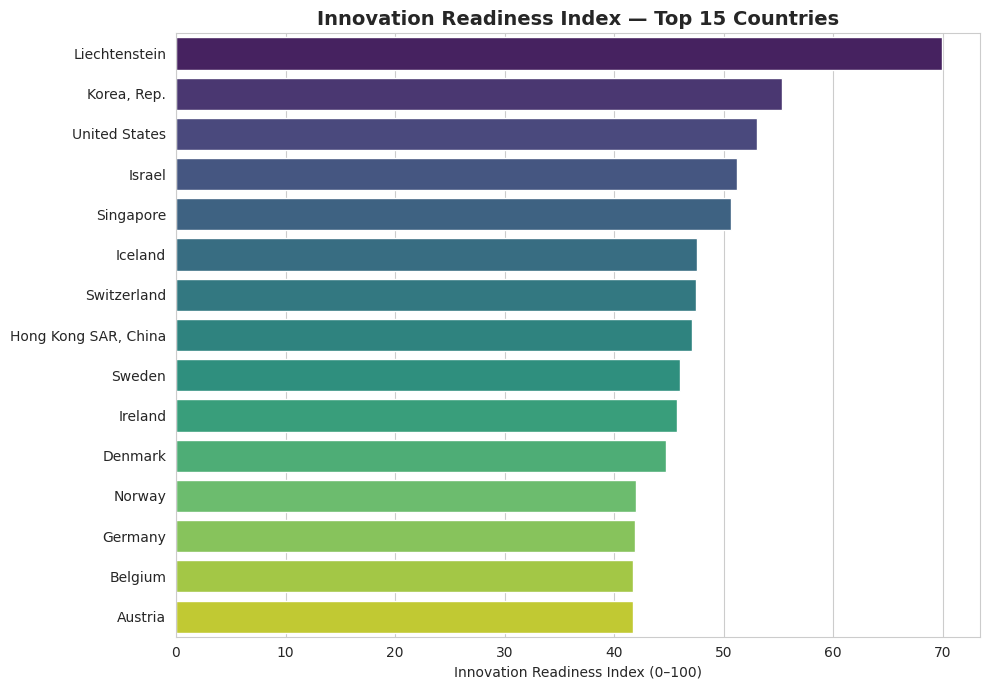

In [6]:
# =====================================================
# CELL 5 — Visual 1: Top 15 ranking
# =====================================================
top15 = df.sort_values("innovation_index", ascending=False).head(15)
plt.figure(figsize=(10, 7))
sns.barplot(data=top15, y="country", x="innovation_index", palette="viridis")
plt.title("Innovation Readiness Index — Top 15 Countries", fontsize=14, weight="bold")
plt.xlabel("Innovation Readiness Index (0–100)")
plt.ylabel("")
plt.tight_layout()
plt.show()

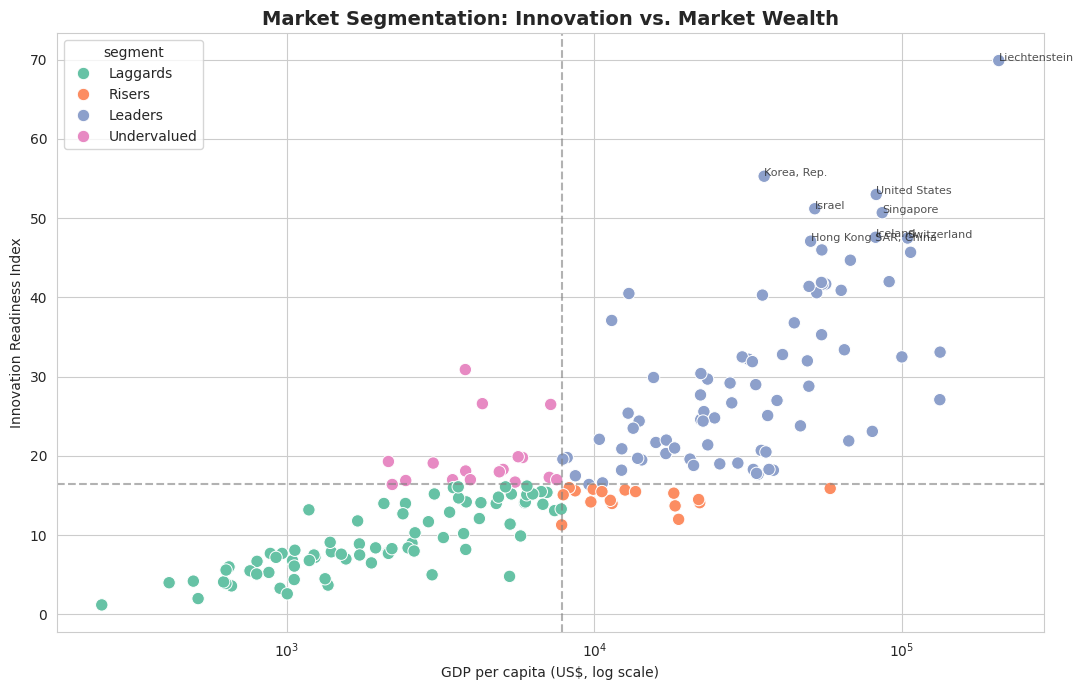

In [7]:
# =====================================================
# CELL 6 — Visual 2: Market segmentation (the strategy piece)
# =====================================================
# X = market attractiveness (wealth), Y = innovation capacity.
# Splitting on medians gives four strategic quadrants.
x = df["gdp_per_capita"]
y = df["innovation_index"]
x_med, y_med = x.median(), y.median()

def segment(row):
    hi_mkt = row["gdp_per_capita"] >= x_med
    hi_inno = row["innovation_index"] >= y_med
    if hi_mkt and hi_inno:   return "Leaders"
    if not hi_mkt and hi_inno: return "Undervalued"   # innovation without the wealth premium
    if hi_mkt and not hi_inno: return "Risers"
    return "Laggards"

df["segment"] = df.apply(segment, axis=1)

plt.figure(figsize=(11, 7))
sns.scatterplot(data=df, x="gdp_per_capita", y="innovation_index",
                hue="segment", s=80, palette="Set2")
plt.axvline(x_med, ls="--", c="grey", alpha=0.6)
plt.axhline(y_med, ls="--", c="grey", alpha=0.6)
plt.xscale("log")
plt.title("Market Segmentation: Innovation vs. Market Wealth", fontsize=14, weight="bold")
plt.xlabel("GDP per capita (US$, log scale)")
plt.ylabel("Innovation Readiness Index")
# Label a few notable points
for _, r in df.sort_values("innovation_index", ascending=False).head(8).iterrows():
    plt.annotate(r["country"], (r["gdp_per_capita"], r["innovation_index"]),
                 fontsize=8, alpha=0.8)
plt.tight_layout()
plt.show()

In [8]:
# =====================================================
# CELL 7 — Light predictive model (the "ML" element)
# =====================================================
# Question: how well do the input factors explain GDP per capita?
# This demonstrates modelling + interpretation, not black-box prediction.
features = ["rd_expenditure_pct_gdp", "researchers_per_million",
            "hightech_exports_pct", "internet_users_pct"]
X = df[features]
y = df["gdp_per_capita"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

print(f"R² on test set: {r2_score(y_test, pred):.3f}")
coef = pd.Series(model.coef_, index=features).sort_values()
print("\nDriver importance (coefficients):")
print(coef.round(2))

R² on test set: 0.515

Driver importance (coefficients):
rd_expenditure_pct_gdp    -520.28
researchers_per_million      7.98
internet_users_pct         240.13
hightech_exports_pct       285.95
dtype: float64


In [9]:
# =====================================================
# CELL 8 — Export findings
# =====================================================
out = df.sort_values("innovation_index", ascending=False)[
    ["country", "innovation_index", "segment"] + metric_cols
]
out.to_csv("innovation_index_results.csv", index=False)
print("Saved. Top undervalued markets:")
print(out[out["segment"] == "Undervalued"].head(5)[["country", "innovation_index"]])

Saved. Top undervalued markets:
         country  innovation_index
191  Philippines              30.9
256     Viet Nam              26.6
236     Thailand              26.5
239        Tonga              19.9
163     Mongolia              19.8


In [10]:
# =====================================================
# CELL 9 — Interactive segmentation dashboard (Plotly)
# =====================================================
import plotly.express as px
import plotly.graph_objects as go

x_med = df["gdp_per_capita"].median()
y_med = df["innovation_index"].median()

fig = px.scatter(
    df,
    x="gdp_per_capita",
    y="innovation_index",
    color="segment",
    size="gdp_total",
    size_max=45,
    hover_name="country",
    hover_data={
        "gdp_per_capita": ":,.0f",
        "innovation_index": ":.1f",
        "rd_expenditure_pct_gdp": ":.2f",
        "researchers_per_million": ":,.0f",
        "hightech_exports_pct": ":.1f",
        "internet_users_pct": ":.1f",
        "gdp_total": False,
        "segment": False,
    },
    log_x=True,
    color_discrete_map={
        "Leaders": "#2E86AB",
        "Undervalued": "#06A77D",
        "Risers": "#F4A261",
        "Laggards": "#C1121F",
    },
    labels={
        "gdp_per_capita": "GDP per capita (US$, log scale)",
        "innovation_index": "Innovation Readiness Index",
        "segment": "Market Segment",
    },
    title="Innovation vs. Market Wealth — Interactive Market Segmentation",
)

# Quadrant divider lines
fig.add_vline(x=x_med, line_dash="dash", line_color="grey", opacity=0.5)
fig.add_hline(y=y_med, line_dash="dash", line_color="grey", opacity=0.5)

# Quadrant labels
fig.add_annotation(x=x_med*4, y=df["innovation_index"].max(), text="LEADERS",
                   showarrow=False, font=dict(size=11, color="#2E86AB"))
fig.add_annotation(x=x_med/3, y=df["innovation_index"].max(), text="UNDERVALUED",
                   showarrow=False, font=dict(size=11, color="#06A77D"))
fig.add_annotation(x=x_med*4, y=df["innovation_index"].min(), text="RISERS",
                   showarrow=False, font=dict(size=11, color="#F4A261"))
fig.add_annotation(x=x_med/3, y=df["innovation_index"].min(), text="LAGGARDS",
                   showarrow=False, font=dict(size=11, color="#C1121F"))

fig.update_layout(template="plotly_white", height=650, title_x=0.5)
fig.show()

# Save an interactive HTML you can host / attach to your portfolio
fig.write_html("innovation_dashboard.html")
print("Saved innovation_dashboard.html")

Saved innovation_dashboard.html


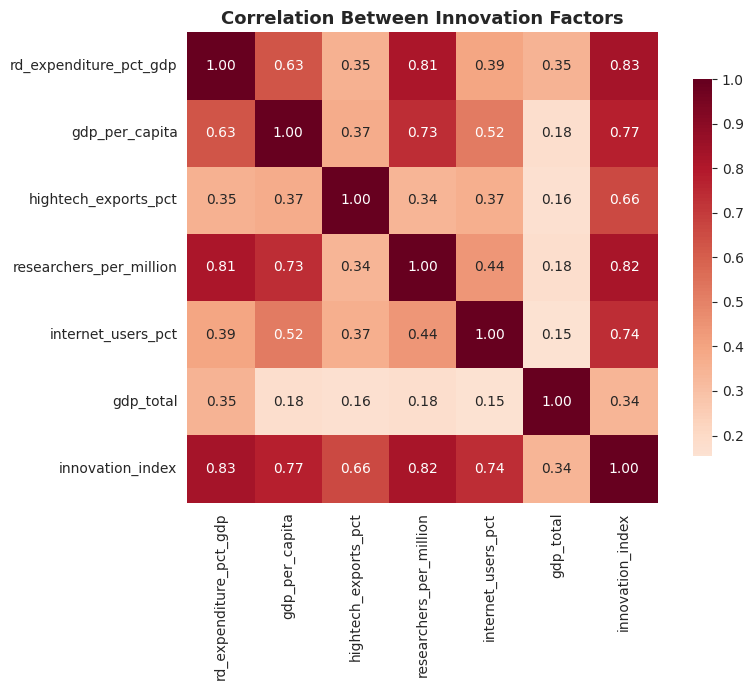

In [11]:
# =====================================================
# CELL 10 — Correlation heatmap (the honest driver analysis)
# =====================================================
corr = df[metric_cols + ["innovation_index"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Between Innovation Factors", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()